<a href="https://colab.research.google.com/github/aviksarkar0204-stack/TruthScanAI/blob/main/notebooks/FakeGuard_Retrain_ClassicML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

In [59]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\Arup
[nltk_data]     sarkar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Arup
[nltk_data]     sarkar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [60]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to C:\Users\Arup
[nltk_data]     sarkar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [61]:
df_fake = pd.read_csv("C:/Users/Arup sarkar/Documents/PythonFile/FakeNewsDetection/Fake.csv")
df_true = pd.read_csv("C:/Users/Arup sarkar/Documents/PythonFile/FakeNewsDetection/True.csv")
df_WEL = pd.read_csv("C:/Users/Arup sarkar/Documents/PythonFile/FakeNewsDetection/WELFake_Dataset.csv")

In [62]:
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [63]:
df_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [64]:
df_WEL.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [65]:
df_true['label'] = 1
df_fake['label'] = 0

In [66]:
df_main1 = pd.concat([df_true, df_fake], axis=0)
df_main1 = df_main1.sample(frac=1,random_state=42).reset_index(drop=True)

In [67]:
df_main1 = df_main1.drop(columns = ["subject", "date"])

In [68]:
df_main1.head()

,title,text,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,0


In [69]:
df_WEL = df_WEL.drop(columns = ["Unnamed: 0"])

In [70]:
df_WEL.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [71]:
df_main = pd.concat([df_WEL, df_main1], axis=0, ignore_index=True)
df_main = df_main.sample(frac=1, random_state=42).reset_index(drop=True)

Let's check the first few rows and the shape of the new `df_main` DataFrame.

In [72]:
display(df_main.head())
print(f"Shape of df_main: {df_main.shape}")

,title,text,label
0,MICHIGAN ELECTOR Receives Violent Death Threat...,,1
1,#Berkeley IRONY ALERT! ANARCHISTS LOOT STARBUC...,Smashing windows How progressive!Protests aga...,1
2,SHOCKER: Public School Turns Computer Lab Into...,,0
3,HALLOWEEN HORROR: Mom Dresses Her Son Up As Hi...,"Same-Sex Marriages, 10 Years LaterDGR @Debbers...",0
4,LOL! JOE BIDEN FLIES TO SERBIA…Is Greeted With...,Hillary can t even find this many supporters t...,1


Shape of df_main: (117032, 3)


In [73]:
df_main.to_csv("MainOne.csv",sep=",")

Text(0.5, 1.0, 'Count Labels')

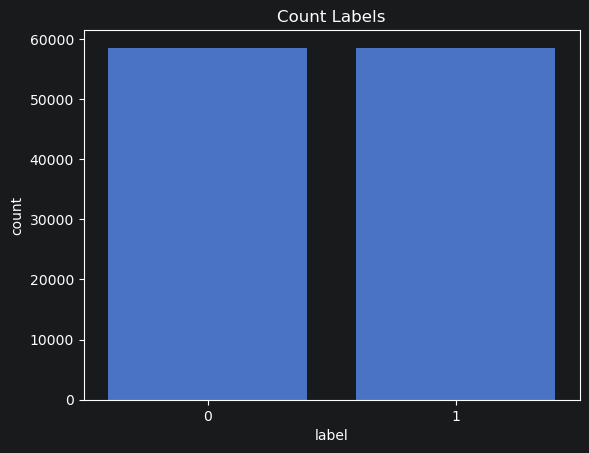

In [74]:
sns.countplot(x='label',data=df_main)
plt.title("Count Labels")

In [75]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117032 entries, 0 to 117031
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   title   116474 non-null  object
 1   text    116993 non-null  object
 2   label   117032 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


In [76]:
label_counts = df_main['label'].value_counts()
print("Count of 0 and 1 values in 'label' column:")
print(label_counts)

Count of 0 and 1 values in 'label' column:
label
1    58523
0    58509
Name: count, dtype: int64


In [77]:
def to_lower(dataframe,column):
    dataframe[column] = dataframe[column].str.lower()
    return dataframe

def remove_html(dataframe, column):
    dataframe[column] = dataframe[column].str.replace(r"<.*?>", " ", regex=True)
    return dataframe

def remove_punctuation(dataframe, column):
    dataframe[column] = dataframe[column].apply(lambda x: re.sub('[^a-zA-Z]', ' ', x))
    return dataframe

def tokenization(dataframe,column):
    dataframe[column] = dataframe[column].apply(lambda x: word_tokenize(x))
    return dataframe

def remove_stopwords(dataframe,column):
    stop_words = stopwords.words('english')
    dataframe[column] = dataframe[column].apply(lambda x:[word for word in x if word not in stop_words])
    return dataframe

def steming(dataframe,column):
    porter = PorterStemmer()
    dataframe[column] = dataframe[column].apply(lambda x: [porter.stem(word) for word in x])
    return dataframe

def list_to_string(dataframe,column):
    dataframe[column] = dataframe[column].apply(lambda x: " ".join(x))
    return dataframe

In [78]:
function_pipeline = {
    "to_lower": to_lower,
    "remove_html": remove_html,
    "remove_punctuation": remove_punctuation,
    "tokenization": tokenization,
    "remove_stopwords": remove_stopwords,
    "steming": steming,
    "list_to_string": list_to_string
}

In [79]:
df_main['content'] = df_main['title'] + ' ' + df_main['text']

In [80]:
df_main.drop(['title', 'text'], axis=1, inplace=True)

In [81]:
df_main

,label,content
0,1,MICHIGAN ELECTOR Receives Violent Death Threat...
1,1,#Berkeley IRONY ALERT! ANARCHISTS LOOT STARBUC...
2,0,SHOCKER: Public School Turns Computer Lab Into...
3,0,HALLOWEEN HORROR: Mom Dresses Her Son Up As Hi...
4,1,LOL! JOE BIDEN FLIES TO SERBIA…Is Greeted With...
...,...,...
117027,1,Ryan has 'full confidence' in House Intelligen...
117028,1,'Big Bang Theory' trumps TV audience for lates...
117029,1,Trump aide plays down prospect of upending 'on...
117030,0,High School Forced to Change Mascot over Accus...


In [82]:
df_main.dropna()

,label,content
0,1,MICHIGAN ELECTOR Receives Violent Death Threat...
1,1,#Berkeley IRONY ALERT! ANARCHISTS LOOT STARBUC...
2,0,SHOCKER: Public School Turns Computer Lab Into...
3,0,HALLOWEEN HORROR: Mom Dresses Her Son Up As Hi...
4,1,LOL! JOE BIDEN FLIES TO SERBIA…Is Greeted With...
...,...,...
117027,1,Ryan has 'full confidence' in House Intelligen...
117028,1,'Big Bang Theory' trumps TV audience for lates...
117029,1,Trump aide plays down prospect of upending 'on...
117030,0,High School Forced to Change Mascot over Accus...


In [83]:
dataframe = df_main

dataframe["content"] = dataframe["content"].fillna("").astype(str)

for name,func in function_pipeline.items():
    print(f"Applying {name} function")
    startTime = time.time()
    dataframe = func(dataframe, "content")
    endTime = time.time()
    print(f"Time taken to apply {name} function: {endTime - startTime:.2f} seconds")

Applying to_lower function
Time taken to apply to_lower function: 0.96 seconds
Applying remove_html function
Time taken to apply remove_html function: 0.16 seconds
Applying remove_punctuation function
Time taken to apply remove_punctuation function: 8.83 seconds
Applying tokenization function
Time taken to apply tokenization function: 163.87 seconds
Applying remove_stopwords function
Time taken to apply remove_stopwords function: 116.59 seconds
Applying steming function
Time taken to apply steming function: 473.15 seconds
Applying list_to_string function
Time taken to apply list_to_string function: 2.02 seconds


In [84]:
X = df_main["content"]
y = df_main["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [85]:
#sklearn pipeline
models = {
    #"Random Forest": RandomForestClassifier(n_estimators=100),
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC()
}
for name, model in models.items():
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('clf', model)
    ])
    print("====================================")
    print(f"Training {name} model...")
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    end_time = time.time()

    duration = end_time - start_time
    print(f"{name}: {score:.4f} | Duration: {duration:.2f} seconds")
    print("=====================================")

Training Logistic Regression model...
Logistic Regression: 0.5075 | Duration: 22.59 seconds
Training Naive Bayes model...
Naive Bayes: 0.5158 | Duration: 19.63 seconds
Training SVM model...
SVM: 0.4053 | Duration: 24.19 seconds
